## 2D Inversion of gravity data

We invert the data along a gravity profile presented by Nickschick et al. (2019), see reference below. It was conducted by Jan Mrlina (Czech Academy of Sciences) and is mainly dominated by a NNW-SSE trending fault with a granite intrusion close to the fault line.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics.gravimetry import GravityModelling2D, depthWeighting

First, we import the data from a normal text file that can be retrieved at the [pyGIMLi example data](https://github.com/gimli-org/example-data/blob/master/grav/)

The data is plotted, representing Fig. 7 of the mentioned paper, except that an offset of 41.5 mGal has been added to shift the curve to around zero in the Western part. The position (along the profile, s. Fig. 1) and the Bouguer anomaly is extracted to `x` and `g`.

03/11/25 - 17:12:27 - pyGIMLi - INFO - Looking for grav/hartousov.txt in gimli-org/example-data/


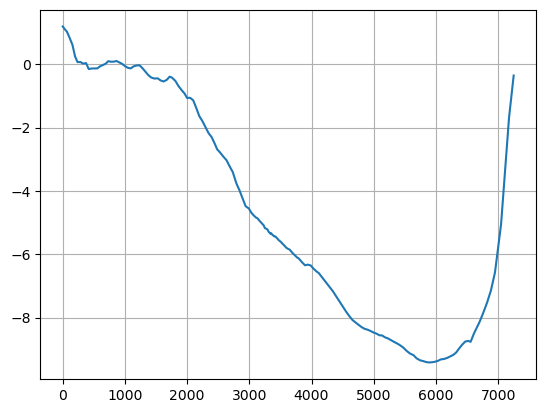

In [2]:
data = pg.getExampleData("grav/hartousov.txt")
x, g = data.T
plt.plot(x, g)
plt.grid();

We create a 1500m deep grid with 100m grid spacing and some surrounding space.

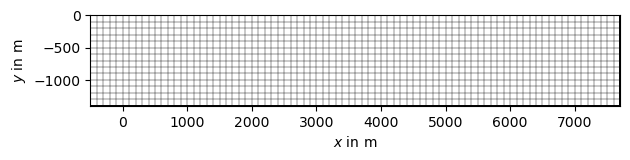

In [3]:
bnd = 500
dep = 1500
dx, dz = 100, 100
grid = pg.createGrid(np.arange(min(x)-bnd, max(x)+bnd, dx), np.arange(0, dep, dz))
grid.scale([1, -1])
grid.show();

Now, the forward and inversion classes are initialized. To restrict the density (difference), a cotangent transform is applied with a maximum derivation of 1000kg/m³. 

In [4]:
points = np.column_stack((x, x*0))
fop = GravityModelling2D(mesh=grid, points=points)
inv = pg.frameworks.Inversion(fop=fop)
inv.modelTrans = pg.trans.TransCotLU(-1000, 1000)

Inversion is called with -g (convention of upward-pointing z axis).

In [5]:
inv.setConstraintWeights(depthWeighting(grid, z0=50, normalize=False))
model = inv.run(-g, absoluteError=0.02, lam=500, zWeight=0.1, verbose=True)

03/11/25 - 17:12:29 - pyGIMLi - INFO - Use median(data values)=5.425999999999998
03/11/25 - 17:12:29 - pyGIMLi - INFO - Created startmodel from forward operator:1148, min/max=5.426000/5.426000
03/11/25 - 17:12:29 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.gravimetry.gravMagModelling.GravityModelling2D object at 0x0000023543777970>
Data transformation: Identity transform
Model transformation: Cotangens LU transform
min/max (data): -1.2/9.42
min/max (error): 0.21%/167%
min/max (start model): 5.43/5.43
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 90829.01
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   93.24 (dPhi = 99.89%) lam: 500.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   65.74 (dPhi = 29.40%) lam: 500.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   27.06 (dPhi = 58.09%) lam: 500.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    3.84 (dPhi = 82.11%) lam: 500.0
-----------------------------------------------------------------

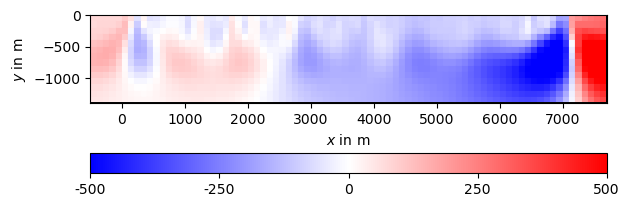

In [6]:
pg.show(grid, model, cMin=-500, cMax=500, cMap="bwr");

## References

Nickschick, T., Flechsig, C., Mrlina, J., Oppermann, F., Löbig, F. & Günther, T. (2019): Large-scale electrical resistivity tomography in the Cheb Basin (Eger Rift) at an ICDP monitoring drill site to image fluid-related structures. Solid Earth 10, 1951-1969, doi:[10.5194/se-10-1951-2019](https://doi.org/10.5194/se-10-1951-2019).